## Test on elastic asynchronous gd

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch

In [ ]:
# ── Synchronous EASGD ─────────────────────────────────────────────────────────
def easgd(grad, num_workers=4, eta=0.01, rho=0.1, num_epochs=300, dim=2):
    alpha = eta * rho

    x_center = np.array([-0.5, 1.5])   # classic hard start for Rosenbrock
    workers = [
        x_center + 1 * np.random.randn(dim)
        for _ in range(num_workers)
    ]

    master_trajectory  = [x_center.copy()]
    worker_trajectories = [[w.copy()] for w in workers]  # one list per worker


    for e in range(num_epochs):
        for i in range(num_workers):
            if e % 50 ==0:
                workers[i] = (workers[i]
                            - alpha * (workers[i] - x_center))
                x_center    = x_center + alpha*(workers[i] - x_center)

            g = grad(workers[i])
            workers[i] = (workers[i]
                            - eta   * g)
            worker_trajectories[i].append(workers[i].copy())  # record after each step

        master_trajectory.append(x_center.copy())

    return x_center, master_trajectory, worker_trajectories

# ── Plain Gradient Descent ────────────────────────────────────────────────────
def plain_gd(grad, eta=0.01, num_epochs=300):
    x = np.array([-0.5, 1.5])
    trajectory = [x.copy()]
    for _ in range(num_epochs):
        x = x - eta * grad(x)
        trajectory.append(x.copy())
    return x, trajectory

In [73]:
# ── Synchronous EASGD ─────────────────────────────────────────────────────────
def easgd_2(grad,fn, theta,num_workers=4, eta=0.01, alpha=0.5,alpha_pull = 0.5,beta=0, num_epochs=300, dim=2):

    x_center = np.asarray(theta, dtype=float)
    workers = [
        x_center + 1 * np.random.randn(dim)
        for _ in range(num_workers)
    ]

    master_trajectory  = [x_center.copy()]
    worker_trajectories = [[w.copy()] for w in workers]  # one list per worker

    for e in range(num_epochs):
        if e % 50 ==0:
            losses = np.array([fn(workers[i]) for i in range(num_workers)])
            w = np.array([np.exp(-beta*losses[i])/np.sum(np.exp(-beta*losses)) for i in range(num_workers)])
            workers = np.array(workers)
            workers_temp = workers
            workers = workers - alpha_pull*w @ (workers - np.array(x_center))
            x_center = (1-alpha)*x_center + alpha * (w @ workers_temp)

            
        g = np.array([grad(workers[i]) for i in range(num_workers)])
        workers = (workers - eta   * g)
        for i in range(num_workers):
            worker_trajectories[i].append(workers[i].copy())  # record after each step

        master_trajectory.append(x_center.copy())

    return x_center, master_trajectory, worker_trajectories

In [8]:
# ── Loss & gradient ───────────────────────────────────────────────────────────
def sphere_fn(theta):
    x, y = theta
    return x**2 + y**2

def sphere_gd(theta):
    x, y = theta
    return np.array([2*x, 2*y])   # FIX: must return a vector, not a scalar


# ── Rosenbrock  f(x,y) = (1-x)² + 100(y-x²)²  —  global min = 0 at (1, 1) ──
def rosenbrock_fn(theta):
    x, y = theta
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_gd(theta):
    x, y = theta
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy =  200 * (y - x**2)
    g = np.array([dfdx, dfdy])
    return np.clip(g, -10.0, 10.0)   # clip to prevent gradient explosion


def rastrigin_fn(theta):
    A = 10
    n = len(theta)
    return A * n + sum(x**2 - A * np.cos(2 * np.pi * x) for x in theta)

def rastrigin_gd(theta):
    A = 10
    return np.array([
        2*x + 2*np.pi*A * np.sin(2 * np.pi * x)
        for x in theta
    ])



In [9]:
# ── Plot ──────────────────────────────────────────────────────────────────────
def draw_path(ax, trajectory, color, label):
    """Draw a trajectory with directional arrows on ax."""
    pts = np.array(trajectory)          # shape (N, 2)
    tx, ty = pts[:, 0], pts[:, 1]

    ax.plot(tx, ty, color=color, linewidth=1.5, alpha=0.8, label=label)
    ax.scatter(tx[0],  ty[0],  s=100, color="lime",  zorder=5)
    ax.scatter(tx[-1], ty[-1], s=100, color=color,   zorder=5, marker="*")

    step = max(1, len(tx) // 15)
    for i in range(0, len(tx) - step, step):
        ax.annotate("",
            xy=(tx[i+step], ty[i+step]),
            xytext=(tx[i], ty[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=1.0),
        )
def plot_trajectories(fn, master_trajectory, gd_trajectory, workers_trajectory,minimum, r=2.0):
    xs = np.linspace(-r, r, 400)
    ys = np.linspace(-r, r * 1.5, 400)   # taller range to capture the valley
    Z  = np.array([[fn(np.array([xi, yj])) for xi in xs] for yj in ys])

    fig, ax = plt.subplots(figsize=(8, 7))
    cp = ax.contourf(xs, ys, np.log1p(Z), levels=60, cmap="viridis")  # log scale so the valley is visible
    plt.colorbar(cp, ax=ax, label="log(1 + Loss)")
    for i in range(len(workers_trajectory)):
        draw_path(ax,workers_trajectory[i], color="blue", label="Worker")
    draw_path(ax, gd_trajectory,     color="tomato", label="Plain GD")
    draw_path(ax, master_trajectory, color="white",  label="EASGD master")

    ax.scatter([], [], s=100, color="lime", label="Start (both)")
    ax.scatter(minimum[0], minimum[1], s=200, color="yellow", marker="*", zorder=6, label="Global min")
    ax.set_xlabel("x"); ax.set_ylabel("y")
    ax.set_title("Plain GD vs EASGD Master — Rosenbrock function")
    ax.legend()
    plt.tight_layout()
    plt.show()

EASGD final loss   : 0.109607
Plain GD final loss: 0.079272


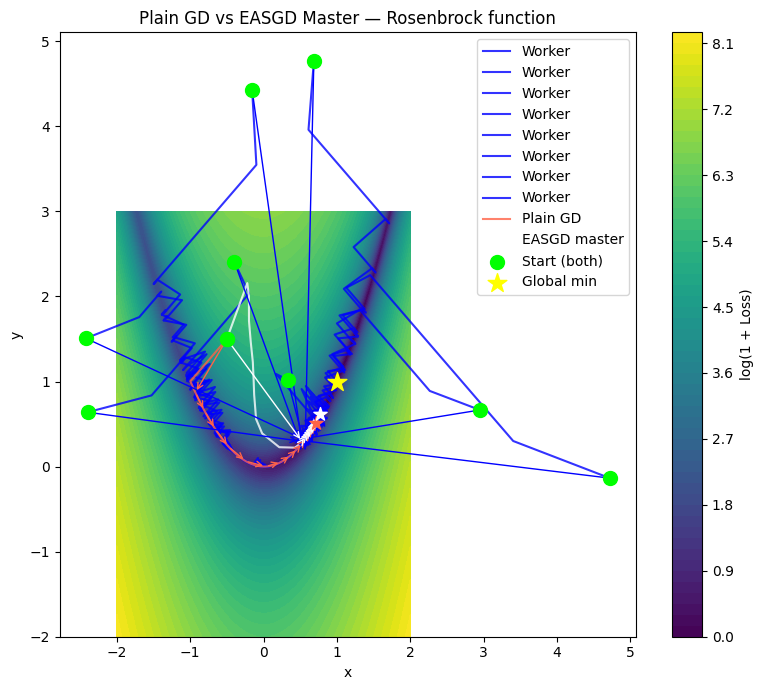

In [38]:
_, master_trajectory, worker_trajectory = easgd(rosenbrock_gd, num_workers=8, eta=0.005, rho=50.0, num_epochs=10000)
_, gd_trajectory        = plain_gd(rosenbrock_gd, eta=0.001, num_epochs=2000)

print(f"EASGD final loss   : {rosenbrock_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {rosenbrock_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(rosenbrock_fn, master_trajectory, gd_trajectory,worker_trajectory,minimum=[1,1], r=2.0)

EASGD final loss   : 0.515597
Plain GD final loss: 0.079272


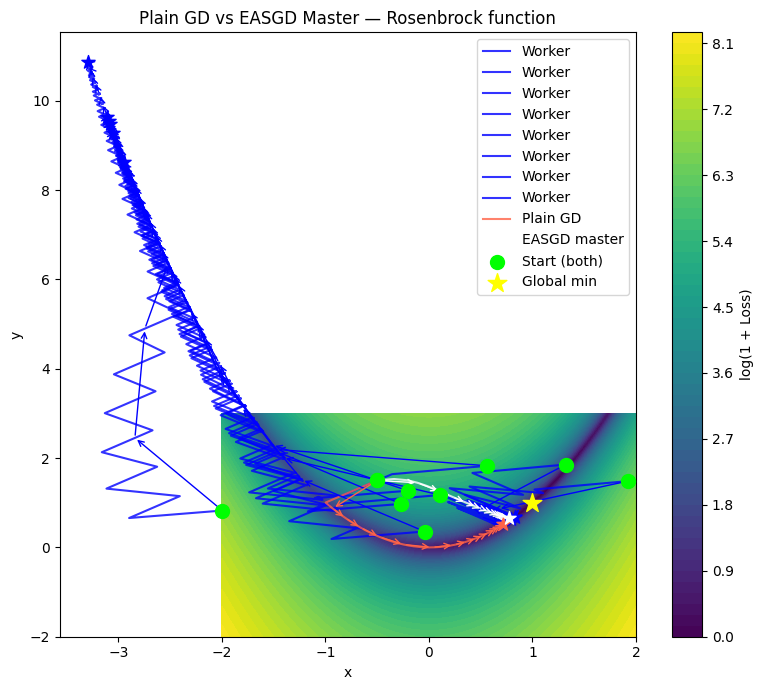

In [74]:
_, master_trajectory, worker_trajectory = easgd_2(rosenbrock_gd, fn=rosenbrock_fn,theta =[-0.5,1.5],num_workers=8,beta=10, eta=0.001, alpha=0.09, num_epochs=2000)
_, gd_trajectory        = plain_gd(rosenbrock_gd, eta=0.001, num_epochs=2000)

print(f"EASGD final loss   : {rosenbrock_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {rosenbrock_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(rosenbrock_fn, master_trajectory, gd_trajectory,worker_trajectory,minimum=[1,1], r=2.0)

In [5]:
_, master_trajectory, worker_trajectory = easgd(sphere_gd, num_workers=2, eta=0.001, rho=0.1, num_epochs=2000)
_, gd_trajectory        = plain_gd(sphere_gd, eta=0.001, num_epochs=2000)

print(f"EASGD final loss   : {sphere_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {sphere_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(sphere_fn, master_trajectory, gd_trajectory,worker_trajectory,minimum=[0,0], r=2.0)

NameError: name 'sphere_gd' is not defined

EASGD final loss   : 42.393280
Plain GD final loss: 0.994959


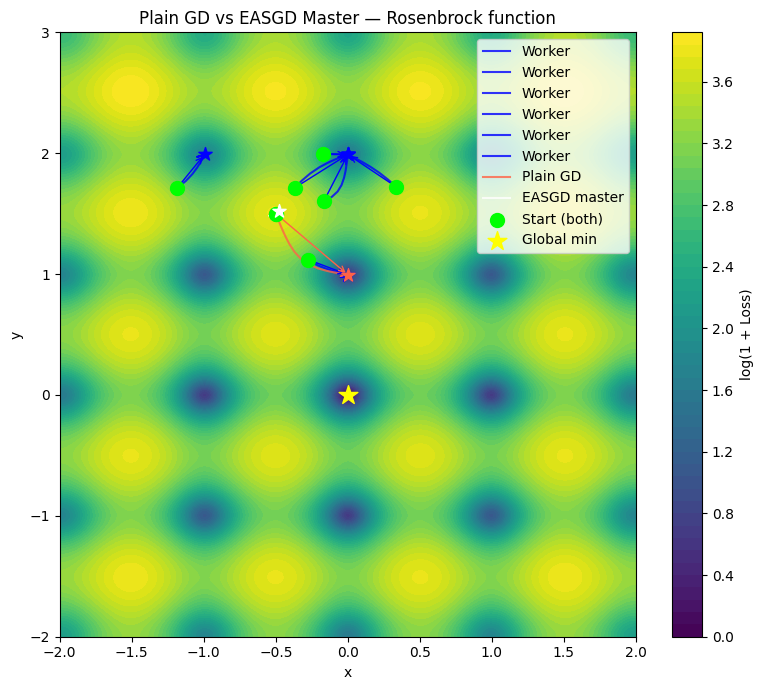

In [7]:
_, master_trajectory, worker_trajectory = easgd(rastrigin_gd, num_workers=6, eta=0.001, rho=0.01, num_epochs=1000)
_, gd_trajectory        = plain_gd(rastrigin_gd, eta=0.001, num_epochs=500)

print(f"EASGD final loss   : {rastrigin_fn(master_trajectory[-1]):.6f}")
print(f"Plain GD final loss: {rastrigin_fn(gd_trajectory[-1]):.6f}")

plot_trajectories(rastrigin_fn, master_trajectory, gd_trajectory,worker_trajectory,minimum=[0,0], r=2.0)

In [51]:
def himmelblau_fn(theta):
    x, y = theta
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def himmelblau_gd(theta):
    x, y = theta
    dfdx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dfdy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.clip(np.array([dfdx, dfdy]), -10.0, 10.0)  # add this

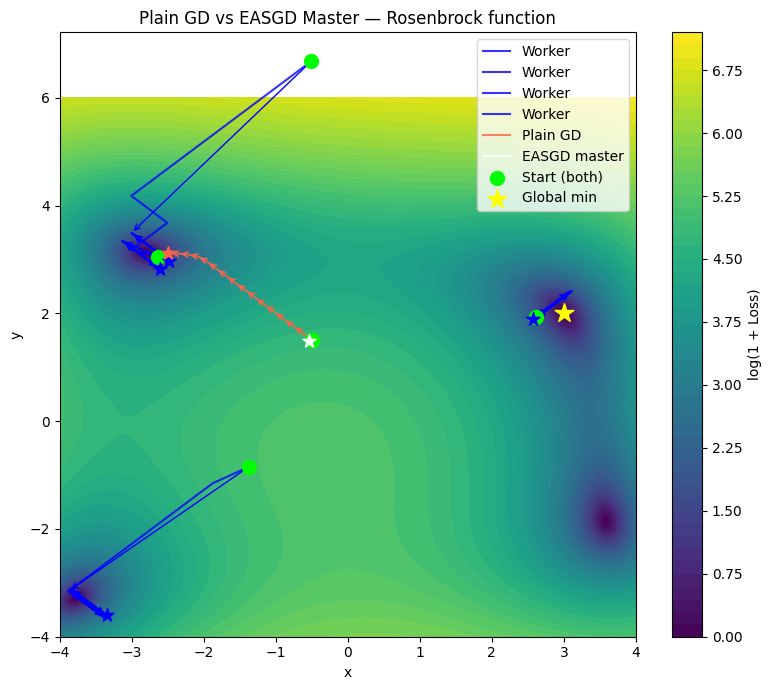

In [28]:
# Use a wider plot range and correct minimum
_, master_trajectory, worker_trajectories = easgd(
    himmelblau_gd, 
    num_workers=4, 
    eta=0.05,   # much smaller — Himmelblau gradients are steep
    rho=0.0001, 
    num_epochs=2000
)
_, gd_trajectory = plain_gd(himmelblau_gd, eta=0.0001, num_epochs=2000)

plot_trajectories(
    himmelblau_fn, 
    master_trajectory, 
    gd_trajectory,
    worker_trajectories,
    minimum=[3, 2],   # one of the 4 actual minima
    r=4.0             # wider range to see all 4 minima
)

C:\Users\Léa\AppData\Local\Temp\ipykernel_15968\663523590.py:16: RuntimeWarning: invalid value encountered in scalar divide
  w = np.array([np.exp(-beta*losses[i])/np.sum(np.exp(-beta*losses)) for i in range(num_workers)])


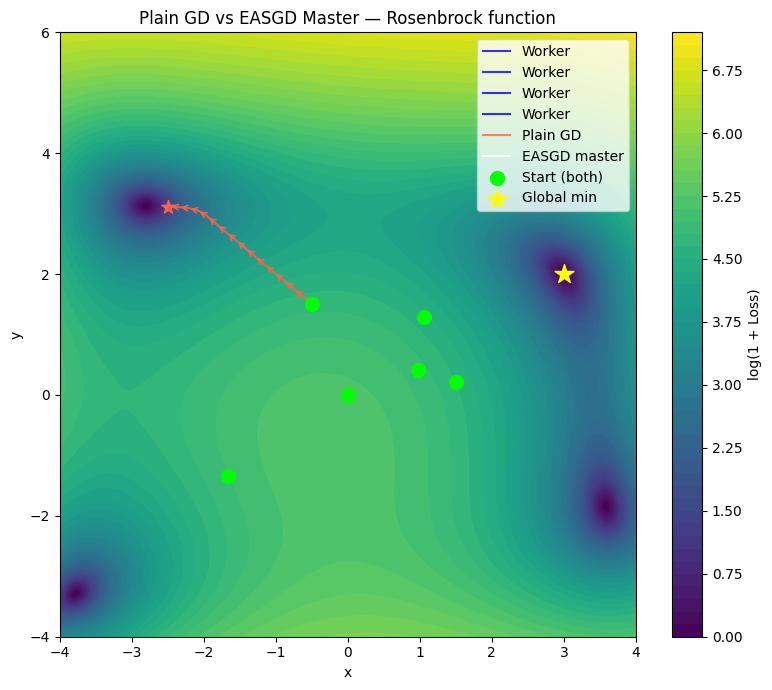

In [82]:
# Use a wider plot range and correct minimum
_, master_trajectory, worker_trajectories = easgd_2(
    himmelblau_gd,
    himmelblau_fn,
    num_workers=4, 
    eta=0.05,
    theta=[0.0,0.0],
    beta = 10,
    alpha=0.8,
    alpha_pull=0.7, 
    num_epochs=2000
)
_, gd_trajectory = plain_gd(himmelblau_gd, eta=0.0001, num_epochs=2000)

plot_trajectories(
    himmelblau_fn, 
    master_trajectory, 
    gd_trajectory,
    worker_trajectories,
    minimum=[3, 2],   # one of the 4 actual minima
    r=4.0             # wider range to see all 4 minima
)

In [18]:
def styblinski_tang_fn(theta):
    raw = 0.5 * sum(x**4 - 16*x**2 + 5*x for x in theta)
    return raw + 80  # shift so values stay positive

def styblinski_tang_gd(theta):
    return np.array([0.5*(4*x**3 - 32*x + 5) for x in theta])

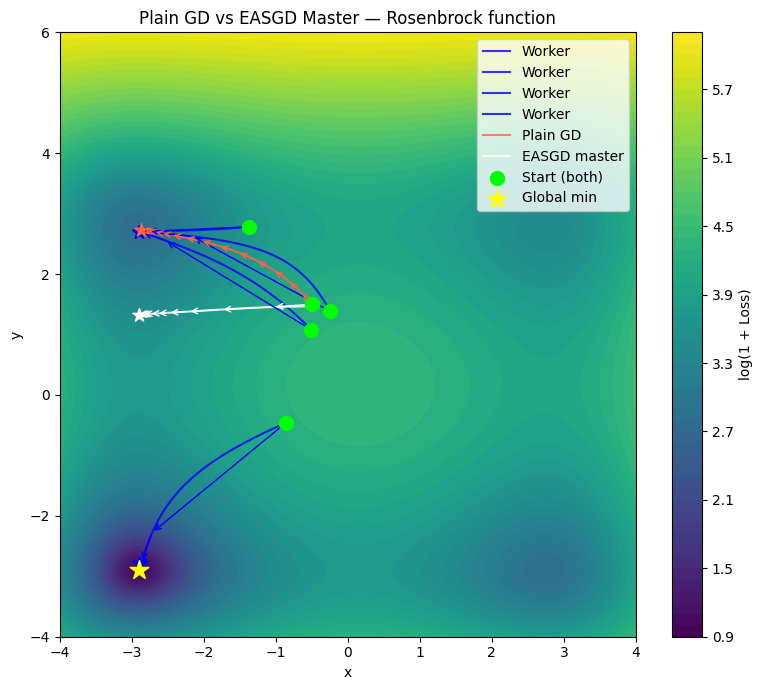

In [25]:
# Use a wider plot range and correct minimum
_, master_trajectory, worker_trajectories = easgd(
    styblinski_tang_gd, 
    num_workers=4, 
    eta=0.001,
    rho=1.0, 
    num_epochs=2000
)
_, gd_trajectory = plain_gd(styblinski_tang_gd, eta=0.0001, num_epochs=2000)

plot_trajectories(
    styblinski_tang_fn, 
    master_trajectory, 
    gd_trajectory,
    worker_trajectories,
    minimum=[-2.9, -2.9],   # one of the 4 actual minima
    r=4.0             # wider range to see all 4 minima
)

In [19]:
def ackley_fn(theta):
    x, y = theta
    return (-20 * np.exp(-0.2 * np.sqrt(0.5*(x**2 + y**2)))
            - np.exp(0.5*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
            + np.e + 20)

def ackley_gd(theta):
    x, y = theta
    r = np.sqrt(0.5*(x**2 + y**2))
    exp1 = np.exp(-0.2 * r)
    exp2 = np.exp(0.5*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
    
    dfdx = (20 * exp1 * 0.2 * (0.5*x/r if r > 1e-10 else 0)
            + exp2 * np.pi * np.sin(2*np.pi*x))
    dfdy = (20 * exp1 * 0.2 * (0.5*y/r if r > 1e-10 else 0)
            + exp2 * np.pi * np.sin(2*np.pi*y))
    return np.clip(np.array([dfdx, dfdy]), -10.0, 10.0)

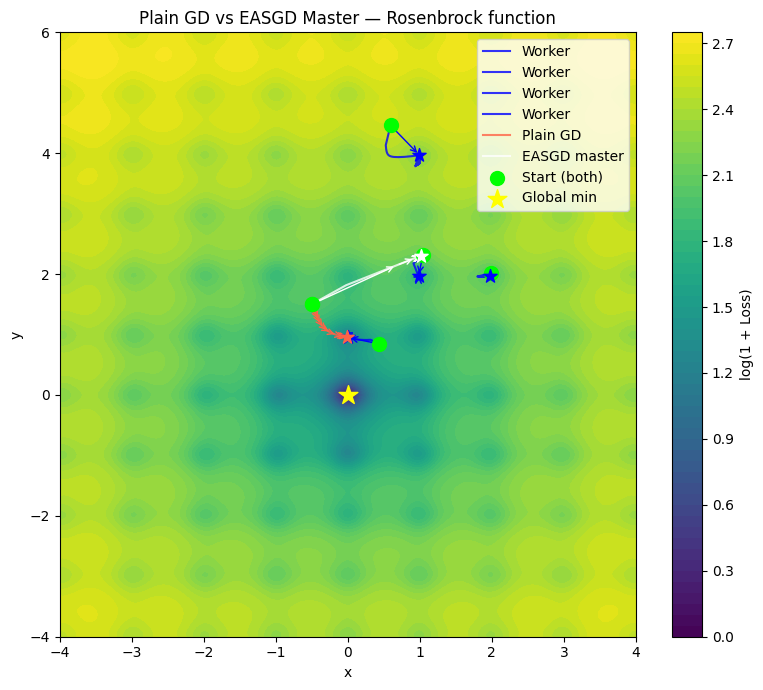

In [20]:

_, master_trajectory, worker_trajectories = easgd(
    ackley_gd, 
    num_workers=4, 
    eta=0.01,
    rho=10.0, 
    num_epochs=3000
)
_, gd_trajectory = plain_gd(ackley_gd, eta=0.0001, num_epochs=2000)

plot_trajectories(
    ackley_fn, 
    master_trajectory, 
    gd_trajectory,
    worker_trajectories,
    minimum=[0, 0],   # one of the 4 actual minima
    r=4.0             # wider range to see all 4 minima
)